In [16]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.metrics import f1_score,accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, log_loss
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from wordcloud import WordCloud
import langdetect
from langdetect import detect, detect_langs, DetectorFactory, LangDetectException
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

import xgboost as xgb
from xgboost import XGBClassifier

# Téléchargement des stopwords si ce n'est pas déjà fait
nltk.download('stopwords')

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Yacinou\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# Lecture des données initiales
X_train_init = pd.read_csv("../data/X_train_update.csv")
y_train_init = pd.read_csv("../data/Y_train_CVw08PX.csv")
X_test_init = pd.read_csv("../data/X_test_update.csv")

# Affichage des informations sur les datasets
print(f"Info X_train_init : {X_train_init.info()}")
print(f"\nInfo Y_train_init : {y_train_init.info()}")
print(f"\nInfo X_test_init : {X_test_init.info()}")

# Affichage des tailles des datasets
print(f"\nTaille X_train_init : {X_train_init.shape}")
print(f"\nTaille Y_train_init : {y_train_init.shape}")
print(f"\nTaille X_test_init : {X_test_init.shape}")

# Affichage du nombre de classes dans la variable cible
print(y_train_init['prdtypecode'].nunique())  # 27 classes

# Merge données d'entrainement dans le dataframe "full_data"
full_data = pd.merge(X_train_init, y_train_init, left_index=True, right_index=True)

# Suppression de la colonne Unnamed: 0_y qui est une colonne d'index inutile
full_data = full_data.drop(['Unnamed: 0_y'], axis=1)

# Renomage de la colonne Unnamed: 0_x en id et mise en index de cette colonne
full_data.rename(columns={'Unnamed: 0_x': 'id'}, inplace=True)  
full_data.set_index(['id'], inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84916 entries, 0 to 84915
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   84916 non-null  int64 
 1   designation  84916 non-null  object
 2   description  55116 non-null  object
 3   productid    84916 non-null  int64 
 4   imageid      84916 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 3.2+ MB
Info X_train_init : None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84916 entries, 0 to 84915
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   84916 non-null  int64
 1   prdtypecode  84916 non-null  int64
dtypes: int64(2)
memory usage: 1.3 MB

Info Y_train_init : None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13812 entries, 0 to 13811
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unn

In [3]:
# Lecture des données
X_train = pd.read_csv("../data/X_train_update.csv")
y_train = pd.read_csv("../data/Y_train_CVw08PX.csv")
X_test = pd.read_csv("../data/X_test_update.csv")

# Affichage des informations sur les datasets
print(f"Info X_train : {X_train.info()}")
print(f"Info Y_train : {y_train.info()}")
print(f"Info X_test : {X_test.info()}")

# Affichage des tailles des datasets
print(f"Taille X_train : {X_train.shape}")
print(f"Taille Y_train : {y_train.shape}")
print(f"Taille X_test : {X_test.shape}")

# Affichage du nombre de classes dans la variable cible
print(y_train['prdtypecode'].nunique())  # 27 classes

# Merge données d'entrainement
full_data = pd.merge(X_train, y_train, left_index=True, right_index=True)

# Suppression de la colonne Unnamed: 0_y qui est une colonne d'index inutile
full_data = full_data.drop(['Unnamed: 0_y'], axis=1)

# Renomage de la colonne Unnamed: 0_x en id et mise en index de cette colonne
full_data.rename(columns={'Unnamed: 0_x': 'id'}, inplace=True)
full_data.set_index(['id'], inplace=True)

X_test.rename(columns={'Unnamed: 0': 'id'}, inplace=True)
X_test.set_index(['id'], inplace=True)

#Longueur des textes
full_data['len_designation'] = (full_data['designation'].astype(str).apply(len))
full_data['len_description'] = (full_data['description'].astype(str).apply(len))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84916 entries, 0 to 84915
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   84916 non-null  int64 
 1   designation  84916 non-null  object
 2   description  55116 non-null  object
 3   productid    84916 non-null  int64 
 4   imageid      84916 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 3.2+ MB
Info X_train : None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84916 entries, 0 to 84915
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   84916 non-null  int64
 1   prdtypecode  84916 non-null  int64
dtypes: int64(2)
memory usage: 1.3 MB
Info Y_train : None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13812 entries, 0 to 13811
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   1

In [4]:
#Fonction de nettoyage du texte simple pour les colonnes de texte
import re

def clean_text(text):
    """
    Nettoyage de base du texte : suppression des balises HTML, des URLs, conversion en minuscules, suppression de la ponctuation et des chiffres.
    """
    if pd.isnull(text):
        return ""

    # Suppression des balises HTML
    text = re.sub(r'<.*?>', '', text)

    # Remplacement des <br /> par un espace
    text = text.replace(r'<br />', ' ')

    # Remplacement des référence de caractère HTML
    text = text.replace(r'&amp;', '&')
    text = text.replace(r'&nbsp;', ' ')
    text = text.replace(r'&lt', '<')
    text = text.replace(r'&gt', '>')
    text = text.replace(r'&quot', '"')
    text = text.replace(r'&#39', "'")
    text = text.replace(r'&eacute', 'e')
    text = text.replace(r'&egrave', 'e')
    text = text.replace(r'&ecirc', 'e')

    # Suppression des URLs et des liens  
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Conversion en minuscules
    text = text.lower()

    # Suppression des espaces supplémentaires
    text = re.sub(r'\s+', ' ', text).strip()

    # Suppression de la ponctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Suppression des chiffres
    text = re.sub(r'\d+', '', text)

    return text

In [5]:
# Nettoyage du texte
full_data['clean_designation'] = full_data['designation'].apply(clean_text)
full_data['clean_description'] = full_data['description'].apply(clean_text)

# Vérification de doublon dans les désignations et descriptions nettoyées
duplicate_designation = full_data['clean_designation'].duplicated().sum()
duplicate_description = full_data['clean_description'].duplicated().sum()

# Concaténation des désignations et descriptions nettoyées pour l'analyse de texte
full_data['text'] = full_data['clean_designation'] + ' ' + full_data['clean_description']

# Création d'un nouveau dataframe pour l'analyse de texte
clean_data = full_data.drop(columns=['designation', 'description', 'productid', 'imageid','clean_designation','clean_description','len_description', 'len_designation',], axis=1)

In [6]:
# Chargement des stopwords français et anglais
stop_fr = set(stopwords.words("french"))  # Stopwords français
stop_en = set(stopwords.words("english"))  # Stopwords anglais
stop_all = stop_fr.union(stop_en)  # Union des deux listes

# "Générique" est un terme générique et non discriminant pour différencier les classes de produits, on l'ajoute à la liste des stopwords
stop_all.add("générique")

def delete_stopwords(text):
    """
    Suppression des mots vides (stopwords)
    """
    return " ".join([w for w in text.split() if w not in stop_all and len(w) > 1])  # Garde mots > 1 caractère

# Application de la suppression des stopwords
clean_data["text_nostop"] = clean_data['text'].apply(delete_stopwords)  # Texte sans stopwords

# Stemming français (réduction des mots à leur racine)
stemmer = SnowballStemmer("french")
def stem_text(text):
    """
    Application du stemming sur chaque mot (réduction à la racine)
    """
    return " ".join([stemmer.stem(w) for w in text.split()])  # Stemming mot par mot

# Application du stemming
clean_data["text_stem"] = clean_data["text_nostop"].apply(stem_text)  # Texte stemmé final

# Fin du processing textuel ci-dessus
# Début de la vectorisation + application des modèles ci-dessous

In [7]:
# Préparation des données pour l'analyse de texte
X = clean_data['text']
y = clean_data['prdtypecode']

# Encodage des labels de la variable cible avec LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Création des ensembles d'entraînement et de test pour l'analyse de texte (20% pour le test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# Initialisation de TfidfVectorizer avec des paramètres pour limiter le nombre de features et les n-grams
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Vectorisation du texte avec TF-IDF
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [8]:
from sklearn.naive_bayes import MultinomialNB

# Création du modèle Naive Bayes Multinomial
nb_clf = MultinomialNB(alpha=1.0)

# Entraînement du modèle Naive Bayes Multinomial 
nb_clf.fit(X_train_tfidf, y_train)

# Prédiction sur l'ensemble de test
y_pred_nb = nb_clf.predict(X_test_tfidf)

# Calcul F1-score pondéré
f1_nb = f1_score(y_test, y_pred_nb, average="weighted")
print("F1-score du modèle Naive Bayes:", f1_nb)


F1-score du modèle Naive Bayes: 0.7073246031650028


              precision    recall  f1-score   support

          10       0.70      0.28      0.40       623
          40       0.80      0.46      0.58       502
          50       0.74      0.67      0.70       336
          60       0.96      0.72      0.82       166
        1140       0.76      0.72      0.74       534
        1160       0.88      0.93      0.90       791
        1180       0.94      0.19      0.32       153
        1280       0.53      0.64      0.58       974
        1281       0.77      0.30      0.43       414
        1300       0.71      0.93      0.80      1009
        1301       0.99      0.64      0.78       161
        1302       0.84      0.50      0.62       498
        1320       0.89      0.55      0.68       648
        1560       0.59      0.77      0.67      1015
        1920       0.85      0.87      0.86       861
        1940       0.98      0.39      0.55       161
        2060       0.55      0.82      0.66       999
        2220       1.00    

<Figure size 1400x1200 with 0 Axes>

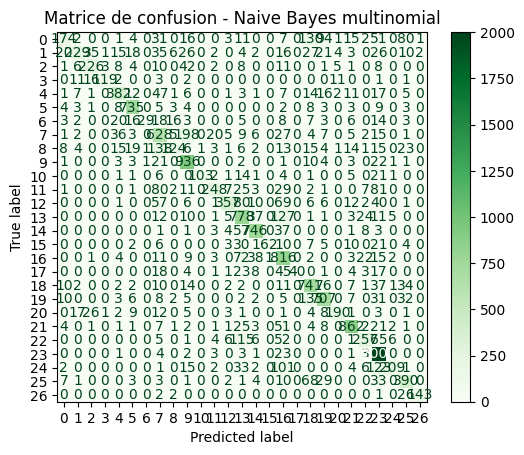

In [9]:
# Affichage du rapport de classification
print(classification_report(y_test, y_pred_nb, target_names=le.classes_.astype(str)))

# Affichage de la matrice de confusion
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(14,12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp.plot(cmap="Greens", values_format="d")
plt.title("Matrice de confusion - Naive Bayes multinomial")
plt.savefig("../reports/figures/viz_txt_NB_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid_nb = {
    "alpha": [0.1, 0.5, 1.0, 2.0]
}
gs_nb = GridSearchCV(
    MultinomialNB(),
    param_grid_nb,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1
)
gs_nb.fit(X_train_tfidf, y_train)
gs_nb.best_params_, gs_nb.best_score_


({'alpha': 0.1}, np.float64(0.7571944618671523))

In [12]:
# Rapport détaillé
print(classification_report(
    y_test, y_pred_nb, 
    target_names=le.classes_.astype(str),
    digits=4
))

# Matrice de confusion
cm_nb = confusion_matrix(y_test, y_pred_nb)

              precision    recall  f1-score   support

          10     0.7045    0.2793    0.4000       623
          40     0.8007    0.4562    0.5812       502
          50     0.7362    0.6726    0.7030       336
          60     0.9597    0.7169    0.8207       166
        1140     0.7564    0.7154    0.7353       534
        1160     0.8760    0.9292    0.9018       791
        1180     0.9355    0.1895    0.3152       153
        1280     0.5327    0.6448    0.5834       974
        1281     0.7654    0.2995    0.4306       414
        1300     0.7064    0.9277    0.8021      1009
        1301     0.9904    0.6398    0.7774       161
        1302     0.8378    0.4980    0.6247       498
        1320     0.8881    0.5509    0.6800       648
        1560     0.5943    0.7665    0.6695      1015
        1920     0.8545    0.8664    0.8604       861
        1940     0.9841    0.3851    0.5536       161
        2060     0.5502    0.8168    0.6575       999
        2220     1.0000    

<Figure size 1400x1200 with 0 Axes>

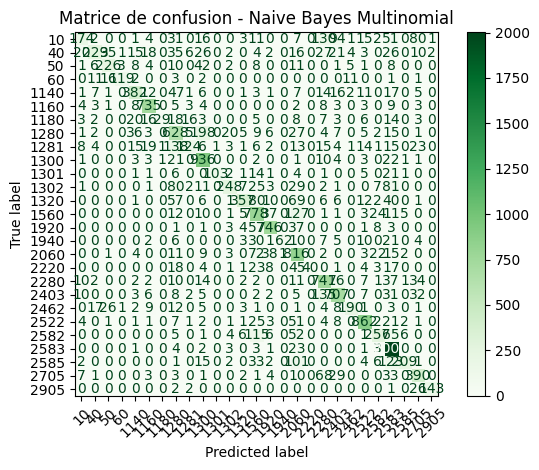

In [13]:
plt.figure(figsize=(14,12))
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=le.classes_.astype(str))
disp_nb.plot(cmap="Greens", values_format="d", xticks_rotation=45)
plt.title("Matrice de confusion - Naive Bayes Multinomial")
plt.tight_layout()
plt.savefig("../reports/figures/viz_txt_NBOpt_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
## Optimisation Naive Bayes
from sklearn.model_selection import GridSearchCV 

# Grille de paramètres pour NB
param_grid_nb = {
    "alpha": [0.1, 0.5, 1.0, 2.0, 5.0]  # Lissage à tester
}

# GridSearch avec CV 3-fold
gs_nb = GridSearchCV(
    MultinomialNB(),  # Modèle de base
    param_grid_nb,  # Paramètres à tester
    scoring="f1_weighted",  # Métrique principale
    cv=3,  # Validation croisée 3-fold
    n_jobs=-1  # Parallélisation
)

# Entraînement optimisé
gs_nb.fit(X_train_tfidf, y_train)  # Fit avec optimisation

# Meilleurs résultats
print(f"Meilleurs paramètres NB: {gs_nb.best_params_}")
print(f"Meilleur F1 CV: {gs_nb.best_score_:.4f}")

# Test final optimisé
y_pred_nb_opt = gs_nb.predict(X_test_tfidf)
f1_nb_opt = f1_score(y_test, y_pred_nb_opt, average="weighted")
print(f"F1 test optimisé: {f1_nb_opt:.4f}")

Meilleurs paramètres NB: {'alpha': 0.1}
Meilleur F1 CV: 0.7572
F1 test optimisé: 0.7675


In [17]:
y_proba = gs_nb.predict_proba(X_test_tfidf)

ce_gsnb = log_loss(y_test, y_proba)
print("Cross-entropy du modèle Naive Bayes optimisé:", ce_gsnb)

Cross-entropy du modèle Naive Bayes optimisé: 0.8874501517120947
